In [93]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
contracts = pd.read_excel('contracts.xlsx')
trades = pd.read_csv('daily_trades.csv')

# Parse dates
trades['trade_date'] = pd.to_datetime(trades['trade_date'])
contracts['t0_date'] = pd.to_datetime(contracts['t0_date'])
contracts['first_trade_date'] = pd.to_datetime(contracts['first_trade_date'])

# Preview
print("Contracts:", len(contracts))
print("Trade rows:", len(trades))
print("\nContracts columns:", contracts.columns.tolist())
print("Trades columns:", trades.columns.tolist())

Contracts: 41
Trade rows: 5189

Contracts columns: ['contract_name', 'group', 'condition_id', 't0_date', 'first_trade_date', 'resolved_outcome', 'information_type']
Trades columns: ['trade_date', 'condition_id', 'question', 'total_volume', 'avg_price', 'num_trades']


In [94]:
# Merge trades with contract metadata on condition_id
df = trades.merge(
    contracts[['condition_id', 'contract_name', 'group', 't0_date', 
               'first_trade_date', 'resolved_outcome', 'information_type']],
    on='condition_id',
    how='left'
)

# Calculate days to event
df['days_to_event'] = (df['trade_date'] - df['t0_date']).dt.days

# Check merge worked
print("Total rows after merge:", len(df))
print("Rows with missing group:", df['group'].isna().sum())
print("Rows with missing t0_date:", df['t0_date'].isna().sum())
print("\nContracts represented:", df['condition_id'].nunique())
print("\nDays to event range:", df['days_to_event'].min(), "to", df['days_to_event'].max())

Total rows after merge: 5189
Rows with missing group: 0
Rows with missing t0_date: 0

Contracts represented: 41

Days to event range: -365 to 29


In [95]:
# For each contract, create a complete date range and fill missing days with zero
all_contracts = df['condition_id'].unique()
filled_rows = []

for cid in all_contracts:
    contract_df = df[df['condition_id'] == cid].copy()
    
    # Get contract metadata
    meta = contracts[contracts['condition_id'] == cid].iloc[0]
    
    # Define full date range from first trade to t0 + 30 days
    date_range = pd.date_range(
        start=contract_df['trade_date'].min(),
        end=meta['t0_date'] + pd.Timedelta(days=30),
        freq='D'
    )
    
    # Reindex to fill missing dates
    contract_df = contract_df.set_index('trade_date').reindex(date_range).reset_index()
    contract_df.rename(columns={'index': 'trade_date'}, inplace=True)
    
    # Fill missing values
    contract_df['condition_id'] = cid
    contract_df['contract_name'] = meta['contract_name']
    contract_df['group'] = meta['group']
    contract_df['t0_date'] = meta['t0_date']
    contract_df['information_type'] = meta['information_type']
    contract_df['total_volume'] = contract_df['total_volume'].fillna(0)
    contract_df['avg_price'] = contract_df['avg_price'].fillna(method='ffill')
    contract_df['num_trades'] = contract_df['num_trades'].fillna(0)
    
    # Recalculate days to event
    contract_df['days_to_event'] = (contract_df['trade_date'] - meta['t0_date']).dt.days
    
    filled_rows.append(contract_df)

df_filled = pd.concat(filled_rows, ignore_index=True)

print("Rows after filling zeros:", len(df_filled))
print("Zero volume days added:", len(df_filled) - len(df))

Rows after filling zeros: 6691
Zero volume days added: 1502


In [96]:
# Define windows
ESTIMATION_START = -60
ESTIMATION_END = -8
EVENT_START = -7
EVENT_END = -1

# Contracts to exclude
EXCLUDE = ['Will Rory McIlroy win The 2026 Masters tournament?']

results = []

for cid in df_filled['condition_id'].unique():
    contract = df_filled[df_filled['condition_id'] == cid].copy()
    meta = contracts[contracts['condition_id'] == cid].iloc[0]
    
    # Skip excluded contracts
    if meta['contract_name'] in EXCLUDE:
        print(f"Excluding {meta['contract_name'][:50]}")
        continue
    
    # Split into windows
    estimation = contract[
        (contract['days_to_event'] >= ESTIMATION_START) & 
        (contract['days_to_event'] <= ESTIMATION_END)
    ]
    event = contract[
        (contract['days_to_event'] >= EVENT_START) & 
        (contract['days_to_event'] <= EVENT_END)
    ]
    
    # Skip if insufficient data
    if len(estimation) < 8 or len(event) < 7:
        print(f"Skipping {meta['contract_name'][:50]} - insufficient data")
        continue
    
    # Volume baseline
    vol_mean = estimation['total_volume'].mean()
    vol_std = estimation['total_volume'].std()
    
    # Price baseline
    price_mean = estimation['avg_price'].mean()
    price_std = estimation['avg_price'].std()
    
    # Avoid division by zero
    if vol_std == 0 or price_std == 0:
        print(f"Skipping {meta['contract_name'][:50]} - zero std dev")
        continue
    
    # Calculate daily abnormal volume and price drift
    av_list = []
    apd_list = []
    
    for day in range(EVENT_START, EVENT_END + 1):
        day_data = event[event['days_to_event'] == day]
        
        if len(day_data) == 0:
            av_list.append(0)
            apd_list.append(0)
        else:
            vol = day_data['total_volume'].values[0]
            price = day_data['avg_price'].values[0]
            
            av = (vol - vol_mean) / vol_std
            apd = abs((price - price_mean) / price_std)
            
            av_list.append(av)
            apd_list.append(apd)
    
    # Cumulate
    cav = sum(av_list)
    capd = sum(apd_list)
    
    # Window flag
    if len(estimation) >= 52:
        window_flag = 'Full'
    elif len(estimation) >= 30:
        window_flag = 'Shortened'
    else:
        window_flag = 'Short'
    
    results.append({
        'condition_id': cid,
        'contract_name': meta['contract_name'],
        'group': meta['group'],
        'information_type': meta['information_type'],
        'resolved_outcome': meta['resolved_outcome'],
        'cav': cav,
        'capd': capd,
        'estimation_days': len(estimation),
        'window_flag': window_flag,
        'av_series': av_list,
        'apd_series': apd_list
    })

results_df = pd.DataFrame(results)
print(f"Contracts analysed: {len(results_df)}")
print(f"\nCAV by group:")
print(results_df.groupby('group')['cav'].mean().round(3))
print(f"\nCAPD by group:")
print(results_df.groupby('group')['capd'].mean().round(3))
print(f"\nWindow flags:")
print(results_df['window_flag'].value_counts())

Excluding Will Rory McIlroy win The 2026 Masters tournament?
Contracts analysed: 40

CAV by group:
group
1.1    25.883
1.2    49.851
2.0    21.848
3.0    12.746
4.0    16.749
Name: cav, dtype: float64

CAPD by group:
group
1.1    7.575
1.2    5.828
2.0    8.659
3.0    5.967
4.0    5.954
Name: capd, dtype: float64

Window flags:
Full         24
Shortened    11
Short         5
Name: window_flag, dtype: int64


In [97]:
from scipy import stats
import numpy as np

# Cluster Group 1.1 properly for CAV
vd_mask = results_df['contract_name'].str.contains('Venezuela|Maduro|War Powers|forces in Venezuela', case=False)
vd_avg = results_df[(results_df['group'] == 1.1) & vd_mask]['cav'].mean()

ziv_mask = results_df['contract_name'].str.contains('Iran.*July|Iran.*Friday', case=False)
ziv_val = results_df[(results_df['group'] == 1.1) & ziv_mask]['cav'].values[0]

spag_mask = results_df['contract_name'].str.contains('Google|Searched', case=False)
spag_vals = results_df[(results_df['group'] == 1.1) & spag_mask]['cav'].values

g1_1_clustered = np.array([vd_avg, ziv_val, *spag_vals])

print(f"Van Dyke cluster CAV: {vd_avg:.3f}")
print(f"Ziv CAV: {ziv_val:.3f}")
print(f"Spagnuolo CAV values: {spag_vals.tolist()}")

# Group arrays
g1_2 = results_df[results_df['group'] == 1.2]['cav'].values
g2 = results_df[results_df['group'] == 2.0]['cav'].values
g3 = results_df[results_df['group'] == 3.0]['cav'].values
g4 = results_df[results_df['group'] == 4.0]['cav'].values
treatment = np.concatenate([g1_1_clustered, g1_2, g2])

print(f"\n=== GROUP SIZES ===")
print(f"Group 1.1 (clustered): {len(g1_1_clustered)}")
print(f"Group 1.2: {len(g1_2)}")
print(f"Group 2: {len(g2)}")
print(f"Group 3: {len(g3)}")
print(f"Group 4: {len(g4)}")
print(f"Treatment combined: {len(treatment)}")

print("\n=== BLOCK 1+2: VALIDATION — CAV ===")

t1, p1 = stats.ttest_1samp(g1_1_clustered, 0)
print(f"\nTest 1 — Group 1.1 (confirmed) vs zero:")
print(f"  Mean CAV: {g1_1_clustered.mean():.3f}, t={t1:.3f}, p={p1:.4f}")

t2, p2 = stats.ttest_1samp(g1_2, 0)
print(f"\nTest 2 — Group 1.2 (literature) vs zero:")
print(f"  Mean CAV: {g1_2.mean():.3f}, t={t2:.3f}, p={p2:.4f}")

print("\n=== BLOCK 2: MAIN TREATMENT — CAV ===")

t3, p3 = stats.ttest_1samp(g2, 0)
print(f"\nTest 3 — Group 2 (structural) vs zero:")
print(f"  Mean CAV: {g2.mean():.3f}, t={t3:.3f}, p={p3:.4f}")

print("\n=== BLOCK 3: GROUP COMPARISONS — CAV ===")

t4, p4 = stats.ttest_ind(treatment, g3, alternative='greater')
print(f"\nTest 4 — Treatment vs Group 3 (matched control):")
print(f"  Treatment mean: {treatment.mean():.3f}, Group 3 mean: {g3.mean():.3f}")
print(f"  t={t4:.3f}, p={p4:.4f}")

t5, p5 = stats.ttest_ind(treatment, g4, alternative='greater')
print(f"\nTest 5 — Treatment vs Group 4 (clean control):")
print(f"  Treatment mean: {treatment.mean():.3f}, Group 4 mean: {g4.mean():.3f}")
print(f"  t={t5:.3f}, p={p5:.4f}")

print("\n=== BLOCK 4: RESOLUTION-APPROACH EFFECT — CAV ===")

t6, p6 = stats.ttest_1samp(g3, 0)
print(f"\nTest 6 — Group 3 vs zero:")
print(f"  Mean CAV: {g3.mean():.3f}, t={t6:.3f}, p={p6:.4f}")

t7, p7 = stats.ttest_1samp(g4, 0)
print(f"\nTest 7 — Group 4 vs zero:")
print(f"  Mean CAV: {g4.mean():.3f}, t={t7:.3f}, p={p7:.4f}")

print("\n=== NON-PARAMETRIC CAV ===")
print(f"Wilcoxon Group 1.1:", stats.wilcoxon(g1_1_clustered))
print(f"Wilcoxon Group 1.2:", stats.wilcoxon(g1_2))
print(f"Wilcoxon Group 2:", stats.wilcoxon(g2))
print(f"Mann-Whitney Treatment vs Group 3:", stats.mannwhitneyu(treatment, g3, alternative='greater'))
print(f"Mann-Whitney Treatment vs Group 4:", stats.mannwhitneyu(treatment, g4, alternative='greater'))
print(f"Wilcoxon Group 3:", stats.wilcoxon(g3))
print(f"Wilcoxon Group 4:", stats.wilcoxon(g4))

Van Dyke cluster CAV: 23.498
Ziv CAV: 80.531
Spagnuolo CAV values: [-0.43903806665178113, 7.097237873331736]

=== GROUP SIZES ===
Group 1.1 (clustered): 4
Group 1.2: 3
Group 2: 5
Group 3: 11
Group 4: 14
Treatment combined: 12

=== BLOCK 1+2: VALIDATION — CAV ===

Test 1 — Group 1.1 (confirmed) vs zero:
  Mean CAV: 27.672, t=1.511, p=0.2280

Test 2 — Group 1.2 (literature) vs zero:
  Mean CAV: 49.851, t=1.710, p=0.2294

=== BLOCK 2: MAIN TREATMENT — CAV ===

Test 3 — Group 2 (structural) vs zero:
  Mean CAV: 21.848, t=1.594, p=0.1862

=== BLOCK 3: GROUP COMPARISONS — CAV ===

Test 4 — Treatment vs Group 3 (matched control):
  Treatment mean: 30.790, Group 3 mean: 12.746
  t=1.543, p=0.0689

Test 5 — Treatment vs Group 4 (clean control):
  Treatment mean: 30.790, Group 4 mean: 16.749
  t=1.307, p=0.1018

=== BLOCK 4: RESOLUTION-APPROACH EFFECT — CAV ===

Test 6 — Group 3 vs zero:
  Mean CAV: 12.746, t=2.933, p=0.0150

Test 7 — Group 4 vs zero:
  Mean CAV: 16.749, t=3.830, p=0.0021

=== N

In [98]:
# Cluster Group 1.1 properly for CAPD
vd_mask = results_df['contract_name'].str.contains('Venezuela|Maduro|War Powers|forces in Venezuela', case=False)
vd_avg_capd = results_df[(results_df['group'] == 1.1) & vd_mask]['capd'].mean()

ziv_mask = results_df['contract_name'].str.contains('Iran.*July|Iran.*Friday', case=False)
ziv_val_capd = results_df[(results_df['group'] == 1.1) & ziv_mask]['capd'].values[0]

spag_mask = results_df['contract_name'].str.contains('Google|Searched', case=False)
spag_vals_capd = results_df[(results_df['group'] == 1.1) & spag_mask]['capd'].values

g1_1_capd_clustered = np.array([vd_avg_capd, ziv_val_capd, *spag_vals_capd])

print(f"Van Dyke cluster CAPD: {vd_avg_capd:.3f}")
print(f"Ziv CAPD: {ziv_val_capd:.3f}")
print(f"Spagnuolo CAPD values: {spag_vals_capd.tolist()}")

# Group arrays
g1_2_capd = results_df[results_df['group'] == 1.2]['capd'].values
g2_capd = results_df[results_df['group'] == 2.0]['capd'].values
g3_capd = results_df[results_df['group'] == 3.0]['capd'].values
g4_capd = results_df[results_df['group'] == 4.0]['capd'].values
treatment_capd = np.concatenate([g1_1_capd_clustered, g1_2_capd, g2_capd])

print("\n=== BLOCK 1+2: VALIDATION — CAPD ===")

t1c, p1c = stats.ttest_1samp(g1_1_capd_clustered, 0)
print(f"\nTest 1 — Group 1.1 (confirmed) vs zero:")
print(f"  Mean CAPD: {g1_1_capd_clustered.mean():.3f}, t={t1c:.3f}, p={p1c:.4f}")

t2c, p2c = stats.ttest_1samp(g1_2_capd, 0)
print(f"\nTest 2 — Group 1.2 (literature) vs zero:")
print(f"  Mean CAPD: {g1_2_capd.mean():.3f}, t={t2c:.3f}, p={p2c:.4f}")

print("\n=== BLOCK 2: MAIN TREATMENT — CAPD ===")

t3c, p3c = stats.ttest_1samp(g2_capd, 0)
print(f"\nTest 3 — Group 2 (structural) vs zero:")
print(f"  Mean CAPD: {g2_capd.mean():.3f}, t={t3c:.3f}, p={p3c:.4f}")

print("\n=== BLOCK 3: GROUP COMPARISONS — CAPD ===")

t4c, p4c = stats.ttest_ind(treatment_capd, g3_capd, alternative='greater')
print(f"\nTest 4 — Treatment vs Group 3 (matched control):")
print(f"  Treatment mean: {treatment_capd.mean():.3f}, Group 3 mean: {g3_capd.mean():.3f}")
print(f"  t={t4c:.3f}, p={p4c:.4f}")

t5c, p5c = stats.ttest_ind(treatment_capd, g4_capd, alternative='greater')
print(f"\nTest 5 — Treatment vs Group 4 (clean control):")
print(f"  Treatment mean: {treatment_capd.mean():.3f}, Group 4 mean: {g4_capd.mean():.3f}")
print(f"  t={t5c:.3f}, p={p5c:.4f}")

print("\n=== BLOCK 4: RESOLUTION-APPROACH EFFECT — CAPD ===")

t6c, p6c = stats.ttest_1samp(g3_capd, 0)
print(f"\nTest 6 — Group 3 vs zero:")
print(f"  Mean CAPD: {g3_capd.mean():.3f}, t={t6c:.3f}, p={p6c:.4f}")

t7c, p7c = stats.ttest_1samp(g4_capd, 0)
print(f"\nTest 7 — Group 4 vs zero:")
print(f"  Mean CAPD: {g4_capd.mean():.3f}, t={t7c:.3f}, p={p7c:.4f}")

print("\n=== NON-PARAMETRIC CAPD ===")
print(f"Wilcoxon Group 1.1:", stats.wilcoxon(g1_1_capd_clustered))
print(f"Wilcoxon Group 1.2:", stats.wilcoxon(g1_2_capd))
print(f"Wilcoxon Group 2:", stats.wilcoxon(g2_capd))
print(f"Mann-Whitney Treatment vs Group 3:", stats.mannwhitneyu(treatment_capd, g3_capd, alternative='greater'))
print(f"Mann-Whitney Treatment vs Group 4:", stats.mannwhitneyu(treatment_capd, g4_capd, alternative='greater'))
print(f"Wilcoxon Group 3:", stats.wilcoxon(g3_capd))
print(f"Wilcoxon Group 4:", stats.wilcoxon(g4_capd))

Van Dyke cluster CAPD: 7.989
Ziv CAPD: 7.383
Spagnuolo CAPD values: [4.240905364789782, 9.443426923125642]

=== BLOCK 1+2: VALIDATION — CAPD ===

Test 1 — Group 1.1 (confirmed) vs zero:
  Mean CAPD: 7.264, t=6.624, p=0.0070

Test 2 — Group 1.2 (literature) vs zero:
  Mean CAPD: 5.828, t=3.115, p=0.0895

=== BLOCK 2: MAIN TREATMENT — CAPD ===

Test 3 — Group 2 (structural) vs zero:
  Mean CAPD: 8.659, t=4.934, p=0.0079

=== BLOCK 3: GROUP COMPARISONS — CAPD ===

Test 4 — Treatment vs Group 3 (matched control):
  Treatment mean: 7.486, Group 3 mean: 5.967
  t=0.991, p=0.1666

Test 5 — Treatment vs Group 4 (clean control):
  Treatment mean: 7.486, Group 4 mean: 5.954
  t=1.231, p=0.1152

=== BLOCK 4: RESOLUTION-APPROACH EFFECT — CAPD ===

Test 6 — Group 3 vs zero:
  Mean CAPD: 5.967, t=4.784, p=0.0007

Test 7 — Group 4 vs zero:
  Mean CAPD: 5.954, t=7.097, p=0.0000

=== NON-PARAMETRIC CAPD ===
Wilcoxon Group 1.1: WilcoxonResult(statistic=0.0, pvalue=0.125)
Wilcoxon Group 1.2: WilcoxonResu

In [99]:
with open('key_results.txt', 'w') as f:
    f.write("=== KEY RESULTS FOR WRITING ===\n")
    f.write("7-DAY EVENT WINDOW — PRIMARY SPECIFICATION\n\n")

    f.write("GROUP MEANS\n")
    for grp, label in [(1.1,'1.1'), (1.2,'1.2'), (2.0,'2'), (3.0,'3'), (4.0,'4')]:
        cav_mean = results_df[results_df['group']==grp]['cav'].mean()
        capd_mean = results_df[results_df['group']==grp]['capd'].mean()
        f.write(f"Group {label} CAV: {cav_mean:.3f}, CAPD: {capd_mean:.3f}\n")

    f.write("\nCLUSTERED VALUES — GROUP 1.1\n")
    f.write(f"Van Dyke  CAV: {vd_avg:.3f}, CAPD: {vd_avg_capd:.3f}\n")
    f.write(f"Ziv       CAV: {ziv_val:.3f}, CAPD: {ziv_val_capd:.3f}\n")
    for i, (c, p) in enumerate(zip(spag_vals.tolist(), spag_vals_capd.tolist())):
        f.write(f"Spagnuolo {i+1} CAV: {c:.3f}, CAPD: {p:.3f}\n")

    f.write("\nBLOCK 1+2: VALIDATION — CAV\n")
    f.write(f"Test 1 Group 1.1: mean={g1_1_clustered.mean():.3f}, t={t1:.3f}, p={p1:.4f}\n")
    f.write(f"Test 2 Group 1.2: mean={g1_2.mean():.3f}, t={t2:.3f}, p={p2:.4f}\n")

    f.write("\nBLOCK 2: MAIN TREATMENT — CAV\n")
    f.write(f"Test 3 Group 2: mean={g2.mean():.3f}, t={t3:.3f}, p={p3:.4f}\n")

    f.write("\nBLOCK 3: GROUP COMPARISONS — CAV\n")
    f.write(f"Test 4 Treatment vs Group 3: treatment={treatment.mean():.3f}, control={g3.mean():.3f}, t={t4:.3f}, p={p4:.4f}\n")
    f.write(f"Test 5 Treatment vs Group 4: treatment={treatment.mean():.3f}, control={g4.mean():.3f}, t={t5:.3f}, p={p5:.4f}\n")

    f.write("\nBLOCK 4: RESOLUTION-APPROACH EFFECT — CAV\n")
    f.write(f"Test 6 Group 3 vs zero: mean={g3.mean():.3f}, t={t6:.3f}, p={p6:.4f}\n")
    f.write(f"Test 7 Group 4 vs zero: mean={g4.mean():.3f}, t={t7:.3f}, p={p7:.4f}\n")

    f.write("\nBLOCK 1+2: VALIDATION — CAPD\n")
    f.write(f"Test 1 Group 1.1: mean={g1_1_capd_clustered.mean():.3f}, t={t1c:.3f}, p={p1c:.4f}\n")
    f.write(f"Test 2 Group 1.2: mean={g1_2_capd.mean():.3f}, t={t2c:.3f}, p={p2c:.4f}\n")

    f.write("\nBLOCK 2: MAIN TREATMENT — CAPD\n")
    f.write(f"Test 3 Group 2: mean={g2_capd.mean():.3f}, t={t3c:.3f}, p={p3c:.4f}\n")

    f.write("\nBLOCK 3: GROUP COMPARISONS — CAPD\n")
    f.write(f"Test 4 Treatment vs Group 3: treatment={treatment_capd.mean():.3f}, control={g3_capd.mean():.3f}, t={t4c:.3f}, p={p4c:.4f}\n")
    f.write(f"Test 5 Treatment vs Group 4: treatment={treatment_capd.mean():.3f}, control={g4_capd.mean():.3f}, t={t5c:.3f}, p={p5c:.4f}\n")

    f.write("\nBLOCK 4: RESOLUTION-APPROACH EFFECT — CAPD\n")
    f.write(f"Test 6 Group 3 vs zero: mean={g3_capd.mean():.3f}, t={t6c:.3f}, p={p6c:.4f}\n")
    f.write(f"Test 7 Group 4 vs zero: mean={g4_capd.mean():.3f}, t={t7c:.3f}, p={p7c:.4f}\n")

    f.write("\nNON-PARAMETRIC\n")
    w1 = stats.wilcoxon(g1_1_clustered)
    w2 = stats.wilcoxon(g1_2)
    w3 = stats.wilcoxon(g2)
    mw3 = stats.mannwhitneyu(treatment, g3, alternative='greater')
    mw4 = stats.mannwhitneyu(treatment, g4, alternative='greater')
    wg3 = stats.wilcoxon(g3)
    wg4 = stats.wilcoxon(g4)
    f.write(f"Wilcoxon Group 1.1 CAV: statistic={w1.statistic}, p={w1.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 1.2 CAV: statistic={w2.statistic}, p={w2.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 2 CAV: statistic={w3.statistic}, p={w3.pvalue:.3f}\n")
    f.write(f"Mann-Whitney Treatment vs Group 3 CAV: statistic={mw3.statistic}, p={mw3.pvalue:.3f}\n")
    f.write(f"Mann-Whitney Treatment vs Group 4 CAV: statistic={mw4.statistic}, p={mw4.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 3 CAV: statistic={wg3.statistic}, p={wg3.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 4 CAV: statistic={wg4.statistic}, p={wg4.pvalue:.3f}\n\n")

    w1c = stats.wilcoxon(g1_1_capd_clustered)
    w2c = stats.wilcoxon(g1_2_capd)
    w3c = stats.wilcoxon(g2_capd)
    mw3c = stats.mannwhitneyu(treatment_capd, g3_capd, alternative='greater')
    mw4c = stats.mannwhitneyu(treatment_capd, g4_capd, alternative='greater')
    wg3c = stats.wilcoxon(g3_capd)
    wg4c = stats.wilcoxon(g4_capd)
    f.write(f"Wilcoxon Group 1.1 CAPD: statistic={w1c.statistic}, p={w1c.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 1.2 CAPD: statistic={w2c.statistic}, p={w2c.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 2 CAPD: statistic={w3c.statistic}, p={w3c.pvalue:.3f}\n")
    f.write(f"Mann-Whitney Treatment vs Group 3 CAPD: statistic={mw3c.statistic}, p={mw3c.pvalue:.3f}\n")
    f.write(f"Mann-Whitney Treatment vs Group 4 CAPD: statistic={mw4c.statistic}, p={mw4c.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 3 CAPD: statistic={wg3c.statistic}, p={wg3c.pvalue:.3f}\n")
    f.write(f"Wilcoxon Group 4 CAPD: statistic={wg4c.statistic}, p={wg4c.pvalue:.3f}\n")

print("Saved key_results.txt")

Saved key_results.txt


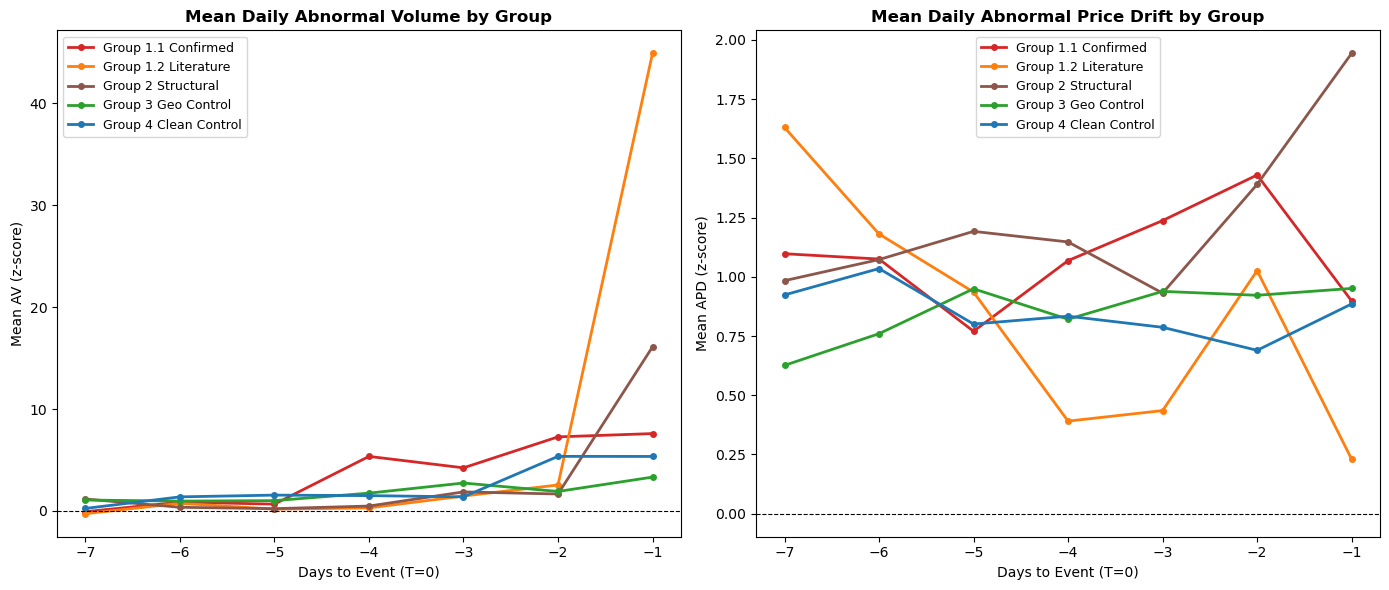

Chart saved


In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
days = list(range(-7, 0))
colors = {'1.1': '#d62728', '1.2': '#ff7f0e', '2.0': '#8c564b', 
          '3.0': '#2ca02c', '4.0': '#1f77b4'}
labels = {'1.1': 'Group 1.1 Confirmed', '1.2': 'Group 1.2 Literature',
          '2.0': 'Group 2 Structural', '3.0': 'Group 3 Geo Control',
          '4.0': 'Group 4 Clean Control'}

for group_val in [1.1, 1.2, 2.0, 3.0, 4.0]:
    group_data = results_df[results_df['group'] == group_val]
    av_matrix = np.array(group_data['av_series'].tolist())
    apd_matrix = np.array(group_data['apd_series'].tolist())
    key = str(group_val)
    axes[0].plot(days, av_matrix.mean(axis=0), 
                label=labels[key], color=colors[key], linewidth=2, marker='o', markersize=4)
    axes[1].plot(days, apd_matrix.mean(axis=0),
                label=labels[key], color=colors[key], linewidth=2, marker='o', markersize=4)

for ax in axes:
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Days to Event (T=0)')
    ax.legend(fontsize=9)
    ax.set_xticks(days)

axes[0].set_title('Mean Daily Abnormal Volume by Group', fontweight='bold')
axes[0].set_ylabel('Mean AV (z-score)')
axes[1].set_title('Mean Daily Abnormal Price Drift by Group', fontweight='bold')
axes[1].set_ylabel('Mean APD (z-score)')

plt.tight_layout()
plt.savefig('event_window_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

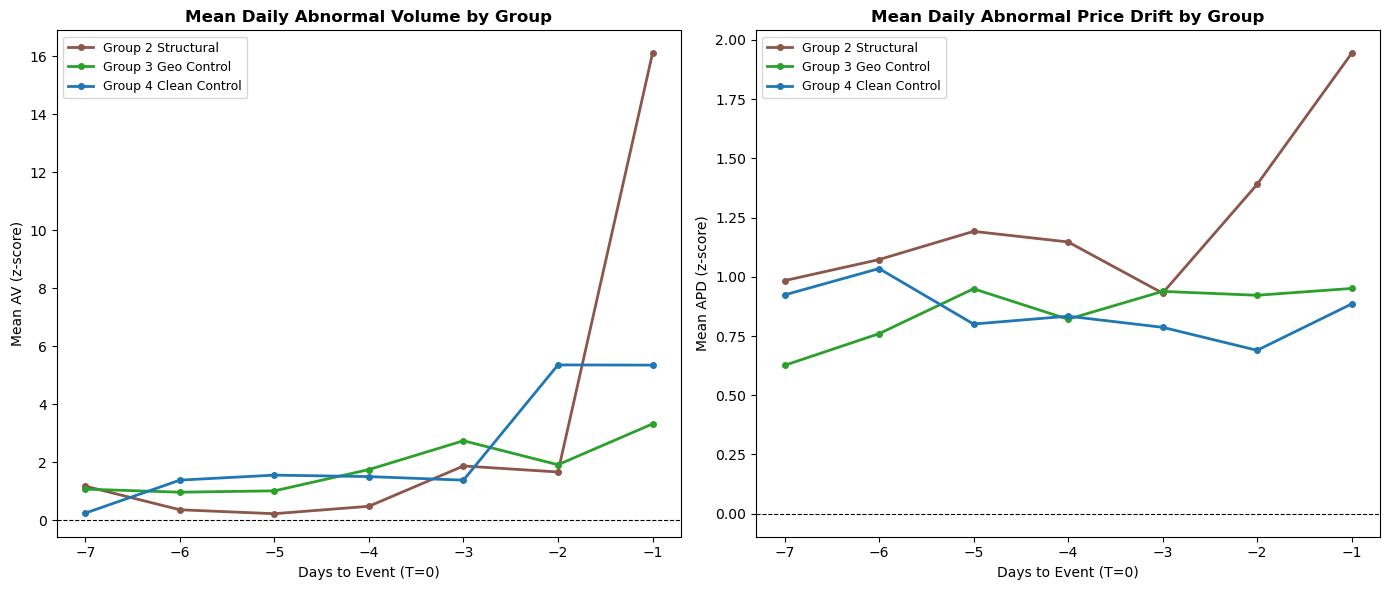

Chart saved


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
days = list(range(-7, 0))
colors = {'1.1': '#d62728', '1.2': '#ff7f0e', '2.0': '#8c564b', 
          '3.0': '#2ca02c', '4.0': '#1f77b4'}
labels = {'1.1': 'Group 1.1 Confirmed', '1.2': 'Group 1.2 Literature',
          '2.0': 'Group 2 Structural', '3.0': 'Group 3 Geo Control',
          '4.0': 'Group 4 Clean Control'}

for group_val in [2.0, 3.0, 4.0]:
    group_data = results_df[results_df['group'] == group_val]
    av_matrix = np.array(group_data['av_series'].tolist())
    apd_matrix = np.array(group_data['apd_series'].tolist())
    key = str(group_val)
    axes[0].plot(days, av_matrix.mean(axis=0), 
                label=labels[key], color=colors[key], linewidth=2, marker='o', markersize=4)
    axes[1].plot(days, apd_matrix.mean(axis=0),
                label=labels[key], color=colors[key], linewidth=2, marker='o', markersize=4)

for ax in axes:
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Days to Event (T=0)')
    ax.legend(fontsize=9)
    ax.set_xticks(days)

axes[0].set_title('Mean Daily Abnormal Volume by Group', fontweight='bold')
axes[0].set_ylabel('Mean AV (z-score)')
axes[1].set_title('Mean Daily Abnormal Price Drift by Group', fontweight='bold')
axes[1].set_ylabel('Mean APD (z-score)')

plt.tight_layout()
plt.savefig('event_window_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved")

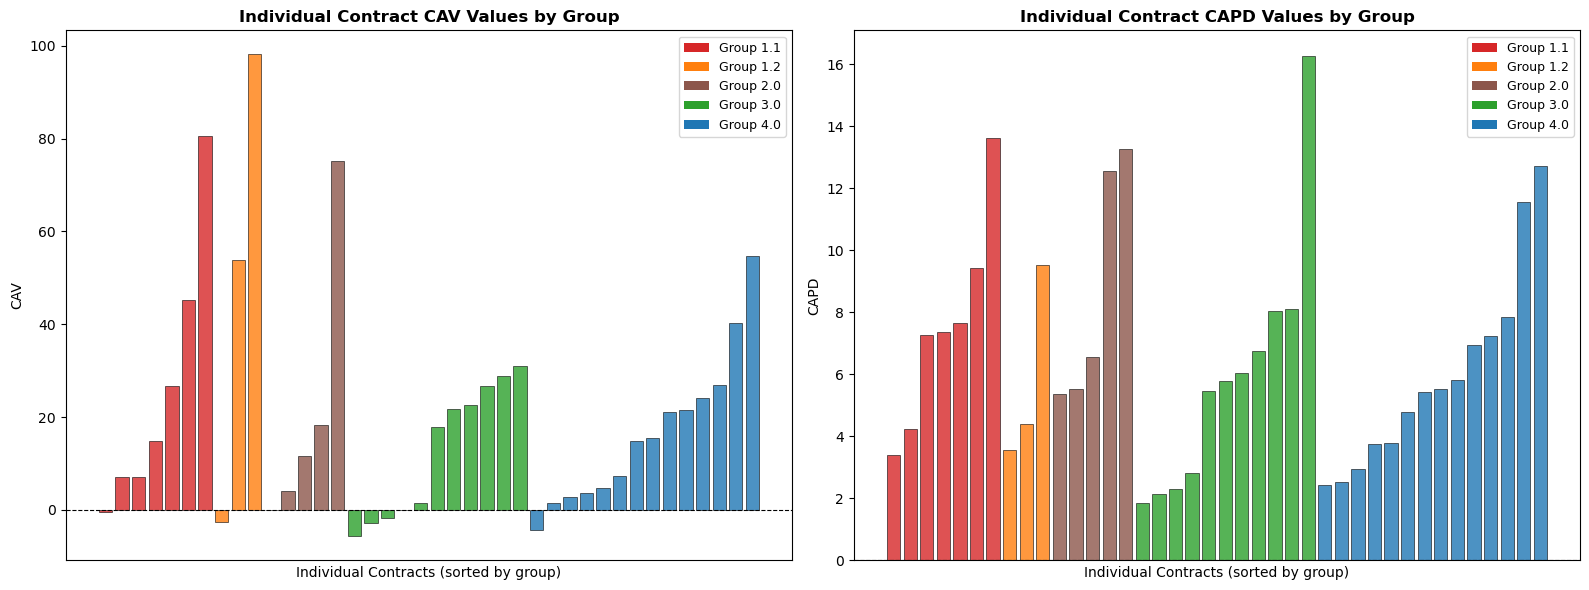

Saved individual_contracts.png


In [102]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

color_map = {1.1: '#d62728', 1.2: '#ff7f0e', 2.0: '#8c564b', 
             3.0: '#2ca02c', 4.0: '#1f77b4'}

for ax, metric in zip(axes, ['cav', 'capd']):
    sorted_df = results_df.sort_values(['group', metric])
    colors = [color_map[g] for g in sorted_df['group']]
    bars = ax.bar(range(len(sorted_df)), sorted_df[metric], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Individual Contracts (sorted by group)')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'Individual Contract {metric.upper()} Values by Group', fontweight='bold')
    ax.set_xticks([])
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=color_map[g], label=f'Group {g}') 
                      for g in [1.1, 1.2, 2.0, 3.0, 4.0]]
    ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('individual_contracts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved individual_contracts.png")

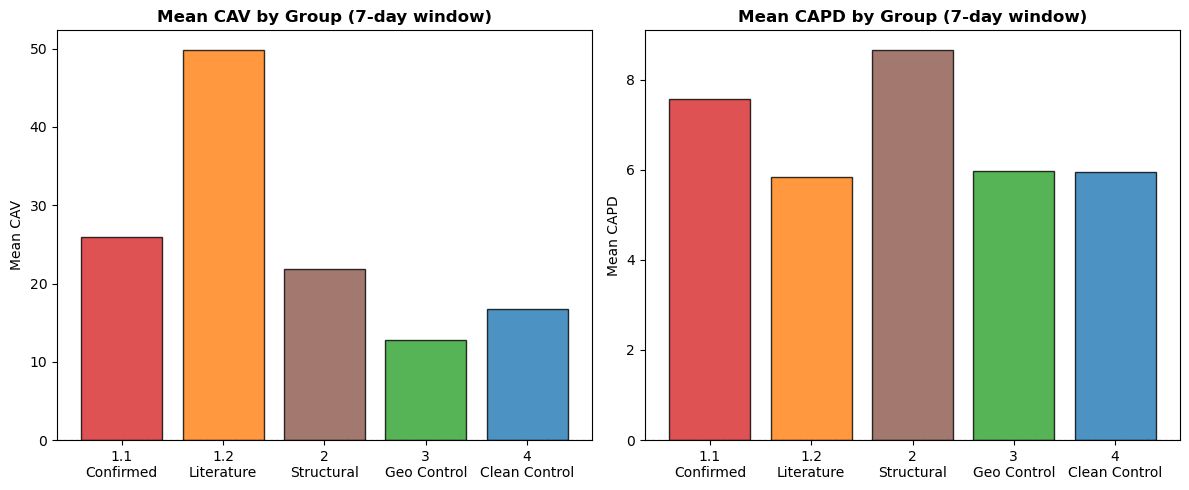

Saved group_means.png


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

groups = ['1.1\nConfirmed', '1.2\nLiterature', '2\nStructural', 
          '3\nGeo Control', '4\nClean Control']
cav_means = [25.883, 49.851, 21.848, 12.746, 16.749]
capd_means = [7.575, 5.828, 8.659, 5.967, 5.954]
colors = ['#d62728', '#ff7f0e', '#8c564b', '#2ca02c', '#1f77b4']

axes[0].bar(groups, cav_means, color=colors, alpha=0.8, edgecolor='black')
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Mean CAV by Group (7-day window)', fontweight='bold')
axes[0].set_ylabel('Mean CAV')

axes[1].bar(groups, capd_means, color=colors, alpha=0.8, edgecolor='black')
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Mean CAPD by Group (7-day window)', fontweight='bold')
axes[1].set_ylabel('Mean CAPD')

plt.tight_layout()
plt.savefig('group_means.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved group_means.png")

In [105]:
print(results_df.groupby('group')['estimation_days'].agg(['mean', 'median', 'min', 'max', 'count']).round(1))

       mean  median  min  max  count
group                               
1.1    24.1    15.0    9   53      7
1.2    51.0    53.0   47   53      3
2.0    43.4    45.0   33   53      5
3.0    46.5    53.0   29   53     11
4.0    52.6    53.0   47   53     14
